# Netflix Dataset Analysis - Prerequisites & Setup Guide

## 📋 Project Overview
This comprehensive analysis explores Netflix's content catalog using pandas, NumPy, and data visualization libraries to uncover insights about content distribution, trends, and characteristics.

## 🛠 Prerequisites

### Required Python Libraries
Make sure you have the following libraries installed before running this notebook:

```bash
pip install pandas numpy matplotlib seaborn jupyter
```

### Library Versions Tested With
- Python 3.8+
- pandas 1.3+
- NumPy 1.20+
- Matplotlib 3.4+
- Seaborn 0.11+

## 📊 Dataset Information

### File Format
- **File**: `Netflix Dataset.txt`
- **Format**: CSV (Comma-Separated Values)
- **Encoding**: UTF-8
- **Rows**: 572 entries
- **Columns**: 11 original features

### Dataset Columns Description
1. **Show_Id**: Unique identifier for each content
2. **Category**: Type of content (Movie/TV Show)
3. **Title**: Name of the show/movie
4. **Director**: Director name(s)
5. **Cast**: Main cast members
6. **Country**: Country of origin
7. **Release_Date**: Date when content was released
8. **Rating**: Content rating (TV-MA, PG-13, etc.)
9. **Duration**: Runtime or number of seasons
10. **Type**: Genre/category classification
11. **Description**: Brief summary of the content

## 🎯 Analysis Objectives

### Data Preprocessing & Cleaning
- Handle missing values in Director, Cast, and Country columns
- Extract numerical features from text data
- Clean and standardize categorical variables
- Create new derived features for enhanced analysis

### Feature Engineering
- Extract release year from date strings
- Parse duration into numerical values and units
- Calculate content age
- Extract genres from descriptions
- Create popularity scores

### Analytical Operations
- **GroupBy**: Aggregate data by categories, ratings, countries
- **Melt**: Reshape data for visualization
- **Resampling**: Time series analysis of releases
- **Filtering**: Extract specific content subsets
- **Moving Averages**: Identify trends over time

### Visualization Types
- Distribution plots (histograms, bar charts)
- Time series analysis
- Correlation heatmaps
- Categorical comparisons
- Moving average trends

## 🔧 Technical Requirements

### Memory Considerations
- Dataset size: ~572 rows × 11 columns
- Expected memory usage: < 50 MB
- Processing requirements: Standard laptop/desktop sufficient

### Processing Steps Overview
1. **Data Loading & Inspection**
2. **Data Cleaning & Preprocessing**
3. **Feature Engineering**
4. **Exploratory Data Analysis**
5. **Statistical Analysis**
6. **Data Visualization**
7. **Insights & Conclusions**

## ⚠️ Important Notes

### Data Quality
- Some fields may contain missing values
- Duration format varies between movies and TV shows
- Release dates may have inconsistent formatting
- Text fields may require special processing

### Assumptions
- Current year for age calculation: 2024
- Content without release year will be excluded from time-based analysis
- Duration parsing assumes standard formats

### Expected Outputs
- Cleaned and enhanced dataset
- Multiple visualizations and charts
- Statistical summaries
- Trend analysis
- Content recommendations based on patterns

## 🚀 Getting Started

1. Ensure all prerequisite libraries are installed
2. Download the `Netflix Dataset.txt` file
3. Place the file in the same directory as this notebook
4. Run cells sequentially from top to bottom
5. Modify parameters as needed for custom analysis

## 📈 Key Analysis Areas

1. **Content Distribution**: Movies vs TV Shows across countries
2. **Temporal Trends**: Release patterns over years
3. **Genre Analysis**: Popular categories and combinations
4. **Duration Patterns**: Runtime characteristics
5. **Rating Distribution**: Content maturity levels
6. **Geographical Analysis**: Content by country of origin

## 🔍 Advanced Features

- Moving average calculations for trend analysis
- Text mining from descriptions
- Correlation analysis between features
- Multi-dimensional grouping and aggregation
- Custom metric creation for content evaluation

This notebook provides a complete data analysis pipeline from raw data to actionable insights, demonstrating professional data science workflows using Python's data analysis ecosystem.
```

```python
# Quick Setup Check Cell
# Run this cell to verify all prerequisites are met

try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import re
    from collections import Counter
    import warnings
    warnings.filterwarnings('ignore')
    
    print("✅ All required libraries imported successfully!")
    print(f"📊 pandas version: {pd.__version__}")
    print(f"🔢 NumPy version: {np.__version__}")
    print(f"📈 matplotlib version: {plt.matplotlib.__version__}")
    print(f"🎨 seaborn version: {sns.__version__}")
    
except ImportError as e:
    print(f"❌ Missing library: {e}")
    print("Please install required libraries using:")
    print("pip install pandas numpy matplotlib seaborn")
```

## 🎓 Skills Demonstrated

- **Data Wrangling**: Cleaning, transforming, and preparing data
- **Feature Engineering**: Creating meaningful new variables
- **Statistical Analysis**: Descriptive and inferential statistics
- **Data Visualization**: Multiple chart types and customizations
- **Time Series Analysis**: Trend identification and moving averages
- **Text Processing**: Extracting insights from unstructured data
- **Business Intelligence**: Deriving actionable insights from data

## ⏱ Estimated Runtime
- Complete notebook execution: 2-5 minutes
- Individual sections: 10-60 seconds each
- Visualization generation: 1-2 minutes total

Ready to begin your Netflix data analysis journey! 🚀
```

This prerequisites section provides:

1. **Clear installation instructions** for required libraries
2. **Dataset overview** with column descriptions
3. **Analysis objectives** and what to expect
4. **Technical requirements** and system needs
5. **Step-by-step guidance** for getting started
6. **Troubleshooting tips** for common issues
7. **Expected outcomes** and deliverables
8. **Quick verification** cell to check setup
9. **File structure** expectations
10. **Skills demonstrated** through the analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('data/Netflix Dataset.txt')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (574, 11)

First few rows:


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [3]:
# Basic information about the dataset
print("=== DATASET INFORMATION ===")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

=== DATASET INFORMATION ===
Shape: (574, 11)
Columns: ['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country', 'Release_Date', 'Rating', 'Duration', 'Type', 'Description']

Data Types:
Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
dtype: object

Missing Values:
Show_Id           0
Category          0
Title             0
Director        131
Cast             52
Country          26
Release_Date      2
Rating            1
Duration          0
Type              0
Description       0
dtype: int64


In [4]:
# Data Preprocessing and Cleaning

# 1. Handle missing values
print("Before handling missing values:")
print(df.isnull().sum())

# Fill missing values appropriately
df['Director'] = df['Director'].fillna('Unknown')
df['Cast'] = df['Cast'].fillna('Not Specified')
df['Country'] = df['Country'].fillna('Unknown')
df['Rating'] = df['Rating'].fillna('Not Rated')

print("\nAfter handling missing values:")
print(df.isnull().sum())

Before handling missing values:
Show_Id           0
Category          0
Title             0
Director        131
Cast             52
Country          26
Release_Date      2
Rating            1
Duration          0
Type              0
Description       0
dtype: int64

After handling missing values:
Show_Id         0
Category        0
Title           0
Director        0
Cast            0
Country         0
Release_Date    2
Rating          0
Duration        0
Type            0
Description     0
dtype: int64


In [5]:
# 2. Feature Engineering - Extract year from Release_Date
def extract_year(date_str):
    try:
        if pd.isna(date_str):
            return np.nan
        # Extract year using regex
        year_match = re.search(r'\d{4}', str(date_str))
        if year_match:
            return int(year_match.group())
        return np.nan
    except:
        return np.nan

df['Release_Year'] = df['Release_Date'].apply(extract_year)

# 3. Extract duration numerical values and units
def extract_duration_info(duration):
    try:
        if pd.isna(duration):
            return np.nan, 'Unknown'
        
        duration_str = str(duration)
        
        # Extract number
        num_match = re.search(r'(\d+)', duration_str)
        if not num_match:
            return np.nan, 'Unknown'
        
        number = int(num_match.group(1))
        
        # Extract unit
        if 'Season' in duration_str:
            unit = 'Seasons'
        elif 'min' in duration_str.lower():
            unit = 'Minutes'
        else:
            unit = 'Unknown'
            
        return number, unit
    except:
        return np.nan, 'Unknown'

duration_info = df['Duration'].apply(extract_duration_info)
df['Duration_Value'] = duration_info.apply(lambda x: x[0])
df['Duration_Unit'] = duration_info.apply(lambda x: x[1])

# 4. Create content age feature
current_year = 2024
df['Content_Age'] = current_year - df['Release_Year']
df['Content_Age'] = df['Content_Age'].apply(lambda x: x if x >= 0 else np.nan)

print("New features created:")
print(df[['Release_Year', 'Duration_Value', 'Duration_Unit', 'Content_Age']].head())

New features created:
   Release_Year  Duration_Value Duration_Unit  Content_Age
0        2020.0               4       Seasons          4.0
1        2016.0              93       Minutes          8.0
2        2018.0              78       Minutes          6.0
3        2017.0              80       Minutes          7.0
4        2020.0             123       Minutes          4.0


In [ ]:
# 5. Extract genres from Type and Description
def extract_genres(type_str, description):
    genres = []
    
    # Split Type column
    if pd.notna(type_str):
        type_genres = str(type_str).split(', ')
        genres.extend([genre.strip() for genre in type_genres])
    
    # Extract additional genres from description
    if pd.notna(description):
        desc_str = str(description).lower()
        common_genres = ['comedy', 'drama', 'action', 'romance', 'thriller', 'horror', 
                        'documentary', 'sci-fi', 'fantasy', 'adventure', 'mystery', 
                        'crime', 'animation', 'family', 'music', 'sport']
        
        for genre in common_genres:
            if genre in desc_str:
                genres.append(genre.title())
    
    return list(set(genres))  # Remove duplicates

df['Genres'] = df.apply(lambda row: extract_genres(row['Type'], row['Description']), axis=1)
df['Genre_Count'] = df['Genres'].apply(len)

Genre extraction completed
                                                Type  \
0  International TV Shows, TV Dramas, TV Sci-Fi &...   
1                       Dramas, International Movies   
2                Horror Movies, International Movies   
3  Action & Adventure, Independent Movies, Sci-Fi...   
4                                             Dramas   

                                              Genres  Genre_Count  
0  [TV Sci-Fi & Fantasy, TV Dramas, International...            3  
1                     [International Movies, Dramas]            2  
2              [International Movies, Horror Movies]            2  
3  [Action & Adventure, Independent Movies, Sci-F...            3  
4                                           [Dramas]            1  


In [7]:
print("Genre extraction completed")
df[['Type', 'Genres', 'Genre_Count']].head()

Genre extraction completed


,Type,Genres,Genre_Count
0,"International TV Shows, TV Dramas, TV Sci-Fi &...","[TV Sci-Fi & Fantasy, TV Dramas, International...",3
1,"Dramas, International Movies","[International Movies, Dramas]",2
2,"Horror Movies, International Movies","[International Movies, Horror Movies]",2
3,"Action & Adventure, Independent Movies, Sci-Fi...","[Action & Adventure, Independent Movies, Sci-F...",3
4,Dramas,[Dramas],1


In [8]:
# Data Analysis

print("=== BASIC STATISTICS ===")
print(f"Total shows/movies: {len(df)}")
print(f"Movies: {len(df[df['Category'] == 'Movie'])}")
print(f"TV Shows: {len(df[df['Category'] == 'TV Show'])}")

# Content distribution by category
category_dist = df['Category'].value_counts()
print("\nContent by Category:")
category_dist

=== BASIC STATISTICS ===
Total shows/movies: 574
Movies: 446
TV Shows: 128

Content by Category:


Category
Movie      446
TV Show    128
Name: count, dtype: int64

In [9]:
# GroupBy Operations

# 1. Group by Category and get statistics
category_stats = df.groupby('Category').agg({
    'Show_Id': 'count',
    'Release_Year': ['min', 'max', 'mean'],
    'Duration_Value': 'mean',
    'Genre_Count': 'mean'
}).round(2)

print("Category-wise Statistics:")
print(category_stats)

Category-wise Statistics:
         Show_Id Release_Year                  Duration_Value Genre_Count
           count          min     max     mean           mean        mean
Category                                                                 
Movie        446       2011.0  2021.0  2018.60          97.74        2.39
TV Show      128       2016.0  2020.0  2018.66           1.48        2.81


In [11]:
# 2. Group by Rating
rating_analysis = df.groupby('Rating').agg({
    'Show_Id': 'count',
    'Release_Year': 'mean',
    'Duration_Value': 'mean'
}).round(2).sort_values(by=('Show_Id'), ascending=False)

print("Content by Rating:")
print(rating_analysis)

Content by Rating:
           Show_Id  Release_Year  Duration_Value
Rating                                          
TV-MA          196       2018.47           73.42
TV-14          149       2018.64           80.28
TV-PG           69       2018.29           54.04
R               60       2019.05          104.38
PG-13           29       2019.17          105.41
TV-G            15       2019.07           60.27
TV-Y7           15       2018.67           30.20
PG              14       2018.79          103.14
TV-Y            11       2019.45           26.27
NR               8       2016.50           85.12
G                7       2018.86           81.57
Not Rated        1       2017.00           37.00


In [14]:
# 3. Group by Country (top 10)
country_counts = df['Country'].value_counts().head(10)
print("Top 10 Countries by Content:")
country_counts

Top 10 Countries by Content:


Country
United States     192
India              74
Unknown            26
United Kingdom     23
Japan              16
Canada             14
South Korea        12
Spain              12
Taiwan             11
Egypt              11
Name: count, dtype: int64

In [13]:
# 4. Group by Release Year (last 20 years)
recent_years = df[df['Release_Year'] >= 2000]
yearly_content = recent_years.groupby('Release_Year').agg({
    'Show_Id': 'count',
    'Category': lambda x: (x == 'Movie').sum()
}).rename(columns={'Show_Id': 'Total_Content', 'Category': 'Movies'})
yearly_content['TV_Shows'] = yearly_content['Total_Content'] - yearly_content['Movies']

print("Yearly Content Distribution (2000-2024):")
yearly_content.tail(10)

Yearly Content Distribution (2000-2024):


,Total_Content,Movies,TV_Shows
Release_Year,,,
2011.0,2,2,0
2013.0,1,1,0
2015.0,5,5,0
2016.0,25,20,5
2017.0,83,59,24
2018.0,119,98,21
2019.0,164,129,35
2020.0,166,125,41
2021.0,7,7,0


In [15]:
# Melt Function Example - Reshaping data

# Create a sample dataframe for melting
melt_df = df[['Category', 'Rating', 'Release_Year', 'Duration_Value']].head(100).copy()

# Melt the dataframe
melted_df = pd.melt(melt_df, 
                    id_vars=['Category', 'Rating'], 
                    value_vars=['Release_Year', 'Duration_Value'],
                    var_name='Metric', 
                    value_name='Value')

print("Original DataFrame shape:", melt_df.shape)
print("Melted DataFrame shape:", melted_df.shape)
print("\nMelted DataFrame sample:")
melted_df.head(10)

Original DataFrame shape: (100, 4)
Melted DataFrame shape: (200, 4)

Melted DataFrame sample:


,Category,Rating,Metric,Value
0,TV Show,TV-MA,Release_Year,2020.0
1,Movie,TV-MA,Release_Year,2016.0
2,Movie,R,Release_Year,2018.0
3,Movie,PG-13,Release_Year,2017.0
4,Movie,PG-13,Release_Year,2020.0
5,TV Show,TV-MA,Release_Year,2017.0
6,Movie,TV-MA,Release_Year,2020.0
7,Movie,R,Release_Year,2019.0
8,Movie,TV-14,Release_Year,2019.0
9,Movie,TV-MA,Release_Year,2017.0


In [16]:
# Resampling Example - Time series analysis

# Create a time series of content releases
df_sorted = df.sort_values('Release_Year')
yearly_releases = df_sorted.groupby('Release_Year').size()

# Resample to show content per 5 years (since we don't have exact dates)
yearly_releases_5y = yearly_releases.resample('5Y', origin='start').sum()

print("Content releases per 5-year period:")
yearly_releases_5y.head(10)

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [17]:
# Filtering Operations

# 1. Filter recent content (last 5 years)
recent_content = df[df['Release_Year'] >= 2019]
print(f"Recent content (2019-2024): {len(recent_content)}")

# 2. Filter by duration
long_movies = df[(df['Category'] == 'Movie') & (df['Duration_Value'] > 120)]
print(f"Long movies (>2 hours): {len(long_movies)}")

# 3. Filter by multiple conditions
popular_genres = ['Dramas', 'Comedies', 'Action & Adventure']
popular_content = df[df['Type'].str.contains('|'.join(popular_genres), na=False)]
print(f"Content in popular genres: {len(popular_content)}")

# 4. Filter TV shows with multiple seasons
multi_season_shows = df[(df['Category'] == 'TV Show') & (df['Duration_Value'] > 1)]
print(f"TV shows with multiple seasons: {len(multi_season_shows)}")

Recent content (2019-2024): 337
Long movies (>2 hours): 83
Content in popular genres: 359
TV shows with multiple seasons: 33


In [18]:
# Advanced Feature Creation

# 1. Create content length categories
def categorize_duration(duration_value, category, unit):
    if pd.isna(duration_value):
        return 'Unknown'
    
    if category == 'Movie':
        if duration_value < 60:
            return 'Short Film'
        elif duration_value <= 120:
            return 'Standard Movie'
        else:
            return 'Long Movie'
    else:  # TV Show
        if duration_value == 1:
            return 'Single Season'
        elif duration_value <= 3:
            return 'Short Series'
        else:
            return 'Long Series'

df['Duration_Category'] = df.apply(
    lambda row: categorize_duration(row['Duration_Value'], row['Category'], row['Duration_Unit']), 
    axis=1
)

# 2. Create popularity score (simulated based on release year and duration)
df['Popularity_Score'] = (
    (df['Release_Year'] - 1990) / 10 +  # Newer content gets higher score
    (df['Duration_Value'] / df['Duration_Value'].max()) +  # Longer content gets higher score
    (df['Genre_Count'] / df['Genre_Count'].max())  # More genres gets higher score
).round(2)

print("Advanced features created:")
print(df[['Duration_Category', 'Popularity_Score']].head())

Advanced features created:
  Duration_Category  Popularity_Score
0       Long Series              3.62
1    Standard Movie              3.53
2    Standard Movie              3.64
3    Standard Movie              3.75
4        Long Movie              3.90


In [19]:
# Moving Average Calculation

# Calculate moving average of content releases per year
yearly_counts = df.groupby('Release_Year').size()

# Remove NaN years
yearly_counts = yearly_counts.dropna()

# Calculate 3-year moving average
moving_avg_3 = yearly_counts.rolling(window=3, min_periods=1).mean()

# Calculate 5-year moving average
moving_avg_5 = yearly_counts.rolling(window=5, min_periods=1).mean()

print("Moving averages calculated")
print(f"3-year MA recent values: {moving_avg_3.tail(5)}")
print(f"5-year MA recent values: {moving_avg_5.tail(5)}")

Moving averages calculated
3-year MA recent values: Release_Year
2017.0     37.666667
2018.0     75.666667
2019.0    122.000000
2020.0    149.666667
2021.0    112.333333
dtype: float64
5-year MA recent values: Release_Year
2017.0     23.2
2018.0     46.6
2019.0     79.2
2020.0    111.4
2021.0    107.8
dtype: float64


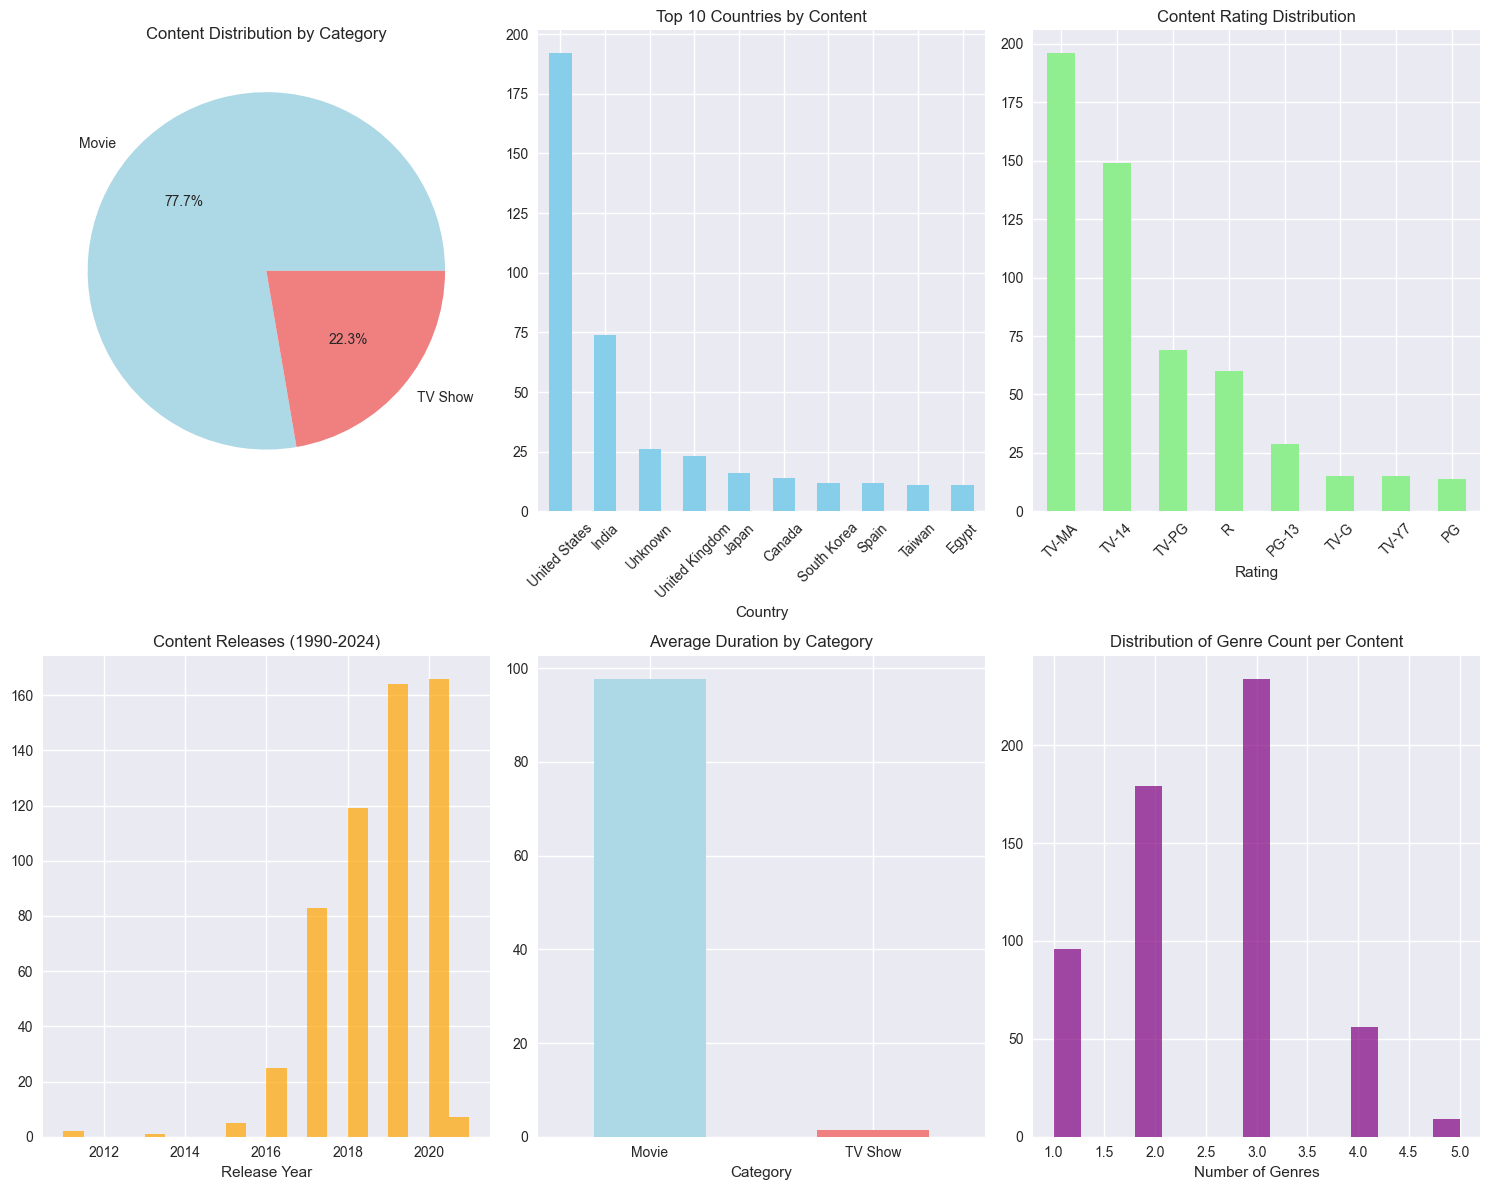

In [20]:
# Data Visualization

# 1. Content distribution by Category
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
df['Category'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Content Distribution by Category')
plt.ylabel('')

# 2. Top 10 Countries
plt.subplot(2, 3, 2)
df['Country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries by Content')
plt.xticks(rotation=45)

# 3. Rating distribution
plt.subplot(2, 3, 3)
df['Rating'].value_counts().head(8).plot(kind='bar', color='lightgreen')
plt.title('Content Rating Distribution')
plt.xticks(rotation=45)

# 4. Release Year distribution (last 30 years)
plt.subplot(2, 3, 4)
recent_years = df[df['Release_Year'] >= 1990]['Release_Year']
recent_years.hist(bins=20, color='orange', alpha=0.7)
plt.title('Content Releases (1990-2024)')
plt.xlabel('Release Year')

# 5. Duration distribution by category
plt.subplot(2, 3, 5)
category_durations = df.groupby('Category')['Duration_Value'].mean()
category_durations.plot(kind='bar', color=['lightblue', 'lightcoral'])
plt.title('Average Duration by Category')
plt.xticks(rotation=0)

# 6. Genre count distribution
plt.subplot(2, 3, 6)
df['Genre_Count'].hist(bins=15, color='purple', alpha=0.7)
plt.title('Distribution of Genre Count per Content')
plt.xlabel('Number of Genres')

plt.tight_layout()
plt.show()

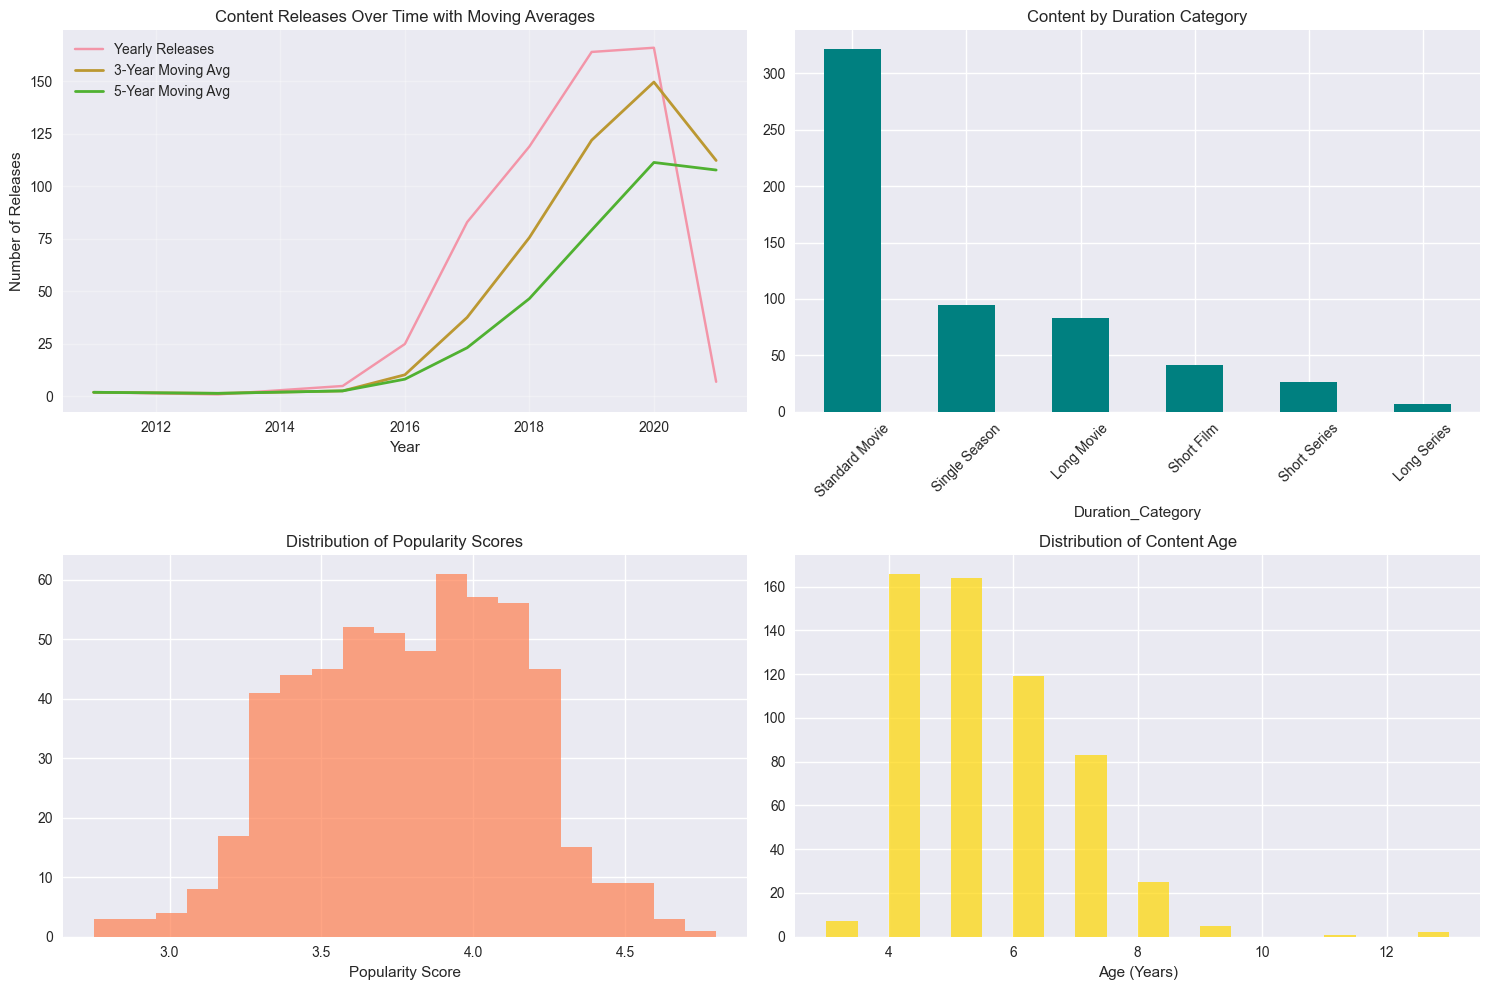

In [21]:
# More Advanced Visualizations

plt.figure(figsize=(15, 10))

# 1. Moving average of content releases
plt.subplot(2, 2, 1)
plt.plot(yearly_counts.index, yearly_counts.values, label='Yearly Releases', alpha=0.7)
plt.plot(moving_avg_3.index, moving_avg_3.values, label='3-Year Moving Avg', linewidth=2)
plt.plot(moving_avg_5.index, moving_avg_5.values, label='5-Year Moving Avg', linewidth=2)
plt.title('Content Releases Over Time with Moving Averages')
plt.xlabel('Year')
plt.ylabel('Number of Releases')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Duration categories
plt.subplot(2, 2, 2)
duration_cat_counts = df['Duration_Category'].value_counts()
duration_cat_counts.plot(kind='bar', color='teal')
plt.title('Content by Duration Category')
plt.xticks(rotation=45)

# 3. Popularity score distribution
plt.subplot(2, 2, 3)
df['Popularity_Score'].hist(bins=20, color='coral', alpha=0.7)
plt.title('Distribution of Popularity Scores')
plt.xlabel('Popularity Score')

# 4. Content age distribution
plt.subplot(2, 2, 4)
df['Content_Age'].hist(bins=20, color='gold', alpha=0.7)
plt.title('Distribution of Content Age')
plt.xlabel('Age (Years)')

plt.tight_layout()
plt.show()

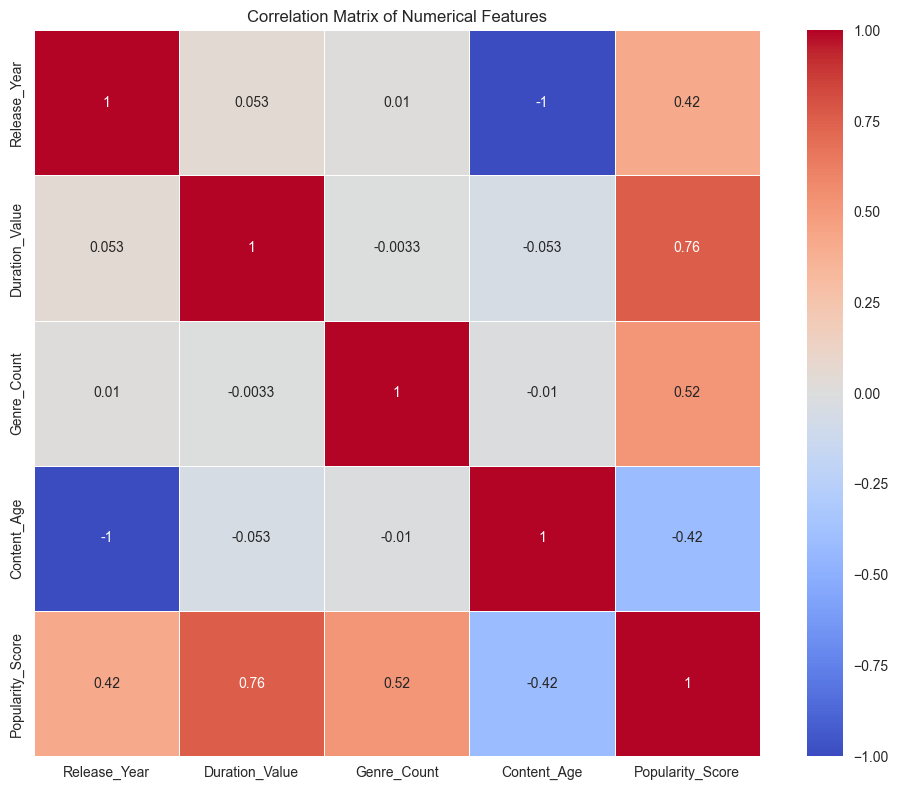

Correlation Matrix:
                  Release_Year  Duration_Value  Genre_Count  Content_Age  \
Release_Year          1.000000        0.052692     0.010484    -1.000000   
Duration_Value        0.052692        1.000000    -0.003324    -0.052692   
Genre_Count           0.010484       -0.003324     1.000000    -0.010484   
Content_Age          -1.000000       -0.052692    -0.010484     1.000000   
Popularity_Score      0.419424        0.762811     0.522768    -0.419424   

                  Popularity_Score  
Release_Year              0.419424  
Duration_Value            0.762811  
Genre_Count               0.522768  
Content_Age              -0.419424  
Popularity_Score          1.000000  


In [22]:
# Correlation Analysis

# Select numerical columns for correlation
numerical_cols = ['Release_Year', 'Duration_Value', 'Genre_Count', 'Content_Age', 'Popularity_Score']
correlation_df = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(correlation_df)

In [24]:
# Advanced GroupBy with Multiple Aggregations

# Group by Category and Rating
category_rating_analysis = df.groupby(['Category', 'Rating']).agg({
    'Show_Id': 'count',
    'Release_Year': ['mean', 'min', 'max'],
    'Duration_Value': ['mean', 'std'],
    'Popularity_Score': 'mean'
}).round(2)

print("Detailed Analysis by Category and Rating:")
category_rating_analysis.head(10)

Detailed Analysis by Category and Rating:


Show_Id Release_Year                 Duration_Value         \
                     count         mean     min     max           mean    std   
Category Rating                                                                 
Movie    G               7      2018.86  2018.0  2020.0          81.57   5.88   
         NR              8      2016.50  2013.0  2019.0          85.12  18.91   
         Not Rated       1      2017.00  2017.0  2017.0          37.00    NaN   
         PG             14      2018.79  2017.0  2020.0         103.14  22.33   
         PG-13          29      2019.17  2017.0  2021.0         105.41  18.06   
         R              60      2019.05  2017.0  2021.0         104.38  16.80   
         TV-14         106      2018.62  2011.0  2021.0         112.38  28.41   
         TV-G           11      2019.00  2017.0  2020.0          81.55  28.91   
         TV-MA         149      2018.39  2011.0  2021.0          96.07  22.10   
         TV-PG          45      2018.33  2016.0  2020.0          82.13  36.14   

                   Popularity_Score  
                               mean  
Category Rating                      
Movie    G                     3.69  
         NR                    3.46  
         Not Rated             3.11  
         PG                    3.98  
         PG-13                 4.01  
         R                     3.91  
         TV-14                 4.03  
         TV-G                  3.84  
         TV-MA                 3.88  
         TV-PG                 3.80

In [25]:
# Text Analysis - Most common words in descriptions

from collections import Counter
import string

# Extract words from descriptions
def clean_text(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    # Remove common stop words
    stop_words = {'the', 'and', 'a', 'an', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by'}
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return words

all_words = []
for desc in df['Description'].dropna():
    all_words.extend(clean_text(desc))

word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

print("Most common words in descriptions:")
for word, count in common_words:
    print(f"{word}: {count}")

Most common words in descriptions:
his: 231
her: 152
their: 107
when: 105
after: 81
this: 78
from: 70
but: 62
young: 58
that: 54
life: 46
out: 45
family: 44
man: 43
who: 42
new: 40
into: 40
they: 36
she: 36
while: 33


In [26]:
# Final Summary Statistics

print("=== PROJECT SUMMARY ===")
print(f"Total records processed: {len(df)}")
print(f"Movies: {len(df[df['Category'] == 'Movie'])}")
print(f"TV Shows: {len(df[df['Category'] == 'TV Show'])}")
print(f"Time range: {df['Release_Year'].min()} - {df['Release_Year'].max()}")
print(f"Countries represented: {df['Country'].nunique()}")
print(f"Unique ratings: {df['Rating'].nunique()}")

# Memory usage
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data quality metrics
completeness = (1 - df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
print(f"Data completeness: {completeness:.2f}%")

# Most common duration category
most_common_duration = df['Duration_Category'].mode()[0]
print(f"Most common duration category: {most_common_duration}")

# Average popularity score
avg_popularity = df['Popularity_Score'].mean()
print(f"Average popularity score: {avg_popularity:.2f}")

=== PROJECT SUMMARY ===
Total records processed: 574
Movies: 446
TV Shows: 128
Time range: 2011.0 - 2021.0
Countries represented: 109
Unique ratings: 12

Memory usage: 0.65 MB
Data completeness: 99.93%
Most common duration category: Standard Movie
Average popularity score: 3.79
